# Предсказание оттока клиентов банка - Exploratory Data Analysis

## 1. Описание задачи

Банки стремятся удерживать клиентов, так как уход (churn) приводит к потере дохода и увеличению затрат на привлечение новых клиентов. Предсказание оттока позволяет банку принимать превентивные меры для удержания клиентов и оптимизации затрат на маркетинг. 

#### **Цель проекта:**  
Предсказать вероятность оттока клиентов на основе исторических данных о поведении, финансовом состоянии и активности клиентов.  

#### **Цель анализа в этом ноутбуке:**
- Исследовать данные клиентов (финансовые, демографические и поведенческие признаки)
- Выявить важные признаки, влияющие на отток
- Подготовить датасет для дальнейшего построения моделей

#### **Описание данных:**  
Датасет содержит 10 000 записей клиентов банка и 18 признаков (после очистки — меньше), включая:  
- Числовые признаки:
  - `CreditScore` — кредитный рейтинг клиента
  - `Age` — возраст клиента
  - `Tenure` — сколько лет клиент обслуживается в банке
  - `Balance` — текущий баланс на счёте
  - `NumOfProducts` — количество продуктов банка, которыми пользуется клиент
  - `HasCrCard` — наличие кредитной карты (0/1)
  - `IsActiveMember` — активность клиента (0/1)
  - `EstimatedSalary` — предполагаемый годовой доход
  - `Satisfaction Score` — оценка удовлетворенности
  - `Point Earned` — баллы за активность
- Категориальные признаки:
  - `Gender` — пол клиента
  - `Geography` — страна клиента
  - `Card Type` — тип карты   
- Целевая переменная:
  - `Exited` — 1 если клиент ушёл, 0 если остался

*Датасет "Bank Customer Churn Prediction" доступен на Kaggle: https://www.kaggle.com/datasets*  

## 2. Импорт библиотек

В ходе работы использованы библиотеки:
- `pandas` - для работы с таблицами
- `matplotlib`, `seaborn` - для визуализации данных
- `display` - для вывода табличных данных
- `joblib` - для сохранения моделей и их метрик
- `sklearn` - инструменты машинного обучения (модели классификации, метрики для исследования качества моделей, разделение данных на тренировочные, валидационные, тестовые выборки)

In [50]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

Настройка отображения данных и графиков

In [51]:
pd.set_option('display.max_columns', None)
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["axes.titlesize"] = 14
plt.rcParams["axes.labelsize"] = 12

## 3. Загрузка и первичный анализ данных:

1. Загружаем CSV-файл с данными клиентов банка.
2. Смотрим размер датасета (количество строк и столбцов).
3. Получаем информацию о типах данных и наличии пропусков (`df.info()` и `df.isnull().sum()`), чтобы понять, какие признаки числовые, а какие категориальные, и нужно ли заполнять пропуски.
4. Выводим статистические показатели числовых признаков (`df.describe()`), включая среднее, стандартное отклонение, минимальные и максимальные значения.
5. Отображаем первые строки датасета (`df.head()`), чтобы визуально убедиться в корректности данных.
6. Определяем категориальные признаки и для тех, у которых мало уникальных значений, показываем распределение значений, чтобы понять, какие признаки можно закодировать в дальнейшем.


In [52]:
df = pd.read_csv("../data/Customer-Churn-Records.csv")

print("Размер:", df.shape)
df.info()
display(df.describe())
df.head()
display(df.isnull().sum())
print("\nКатегориальные столбцы:")
categoricals = df.select_dtypes(include=['object', 'category']).columns
for col in categoricals:
    print(f"{col}: {df[col].nunique()} уникальных значений")
    if df[col].nunique() < 5:
        display(df[col].value_counts().head())

Размер: (10000, 18)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 18 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   RowNumber           10000 non-null  int64  
 1   CustomerId          10000 non-null  int64  
 2   Surname             10000 non-null  object 
 3   CreditScore         10000 non-null  int64  
 4   Geography           10000 non-null  object 
 5   Gender              10000 non-null  object 
 6   Age                 10000 non-null  int64  
 7   Tenure              10000 non-null  int64  
 8   Balance             10000 non-null  float64
 9   NumOfProducts       10000 non-null  int64  
 10  HasCrCard           10000 non-null  int64  
 11  IsActiveMember      10000 non-null  int64  
 12  EstimatedSalary     10000 non-null  float64
 13  Exited              10000 non-null  int64  
 14  Complain            10000 non-null  int64  
 15  Satisfaction Score  10000 non-null

,RowNumber,CustomerId,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Complain,Satisfaction Score,Point Earned
count,10000.00000,1.000000e+04,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,5000.50000,1.569094e+07,650.528800,38.921800,5.012800,76485.889288,1.530200,0.70550,0.515100,100090.239881,0.203800,0.204400,3.013800,606.515100
std,2886.89568,7.193619e+04,96.653299,10.487806,2.892174,62397.405202,0.581654,0.45584,0.499797,57510.492818,0.402842,0.403283,1.405919,225.924839
min,1.00000,1.556570e+07,350.000000,18.000000,0.000000,0.000000,1.000000,0.00000,0.000000,11.580000,0.000000,0.000000,1.000000,119.000000
25%,2500.75000,1.562853e+07,584.000000,32.000000,3.000000,0.000000,1.000000,0.00000,0.000000,51002.110000,0.000000,0.000000,2.000000,410.000000
50%,5000.50000,1.569074e+07,652.000000,37.000000,5.000000,97198.540000,1.000000,1.00000,1.000000,100193.915000,0.000000,0.000000,3.000000,605.000000
75%,7500.25000,1.575323e+07,718.000000,44.000000,7.000000,127644.240000,2.000000,1.00000,1.000000,149388.247500,0.000000,0.000000,4.000000,801.000000
max,10000.00000,1.581569e+07,850.000000,92.000000,10.000000,250898.090000,4.000000,1.00000,1.000000,199992.480000,1.000000,1.000000,5.000000,1000.000000


RowNumber             0
CustomerId            0
Surname               0
CreditScore           0
Geography             0
Gender                0
Age                   0
Tenure                0
Balance               0
NumOfProducts         0
HasCrCard             0
IsActiveMember        0
EstimatedSalary       0
Exited                0
Complain              0
Satisfaction Score    0
Card Type             0
Point Earned          0
dtype: int64


Категориальные столбцы:
Surname: 2932 уникальных значений
Geography: 3 уникальных значений


Geography
France     5014
Germany    2509
Spain      2477
Name: count, dtype: int64

Gender: 2 уникальных значений


Gender
Male      5457
Female    4543
Name: count, dtype: int64

Card Type: 4 уникальных значений


Card Type
DIAMOND     2507
GOLD        2502
SILVER      2496
PLATINUM    2495
Name: count, dtype: int64

### Ключевые наблюдения
- Пропусков нет, все признаки заполнены.  
- Целевая переменная — `Exited`, бинарная.  
- Категориальные признаки: Geography, Gender, Card Type.  
- Признаки RowNumber, CustomerId и Surname не нужны для модели.

## 4. Анализ целевой переменной и выбор метрик

Exited
0    7962
1    2038
Name: count, dtype: int64

<Axes: xlabel='Exited'>

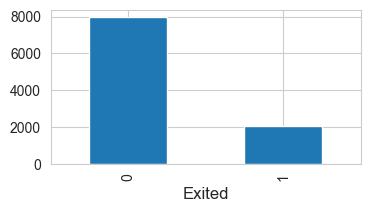

In [53]:
display(df['Exited'].value_counts())
df['Exited'].value_counts().plot(kind='bar', figsize=(4,2))


### Подбор метрик
Так как задача является бинарной классификацией с несбалансированными классами (~20% положительного класса), использование accuracy как основной метрики нецелесообразно.
#### Бизнес-интерпретация ошибок
- False Negative (клиент ушёл, но модель этого не предсказала) → потенциальная потеря дохода.
- False Positive (модель предсказала уход, но клиент остался) → лишние затраты на удерживающее предложение.
В зависимости от бизнес-стратегии возможна настройка порога классификации для увеличения Recall или Precision.
#### Для оценки качества модели будут использоваться следующие метрики:
**ROC-AUC**  
Показывает способность модели различать классы при различных порогах вероятности.
Является устойчивой метрикой для несбалансированных задач и позволяет оценить общее качество ранжирования.   
**Recall (для класса 1)**  
Показывает долю реально ушедших клиентов, которых модель смогла выявить.
Данная метрика важна с точки зрения бизнеса, так как пропуск клиента, который собирался уйти, приводит к финансовым потерям.  
**Precision**  
Показывает долю корректных предсказаний среди клиентов, которым модель предсказала уход.
Важна для оптимизации затрат на удерживающие кампании. Второстепенен по отношению к Recall
**F-beta**  
Гармоническое среднее precision и recall.
Используется для баланса между полнотой и точностью. Так как в нашей задаче значтельно более важной метрикой является Recall, при условии, что Precision не является абсолютно безполезной метрикой, поэтому коэффициент b = 2

| Метрика                  | Бизнес-интерпретация                                                             |
| ------------------------ | ------------------------------------------------------------------------- |
| **Precision**            | Доля правильных предсказаний среди тех, что модель предсказала как «ушёл» |
| **Recall** | Доля правильно найденных ушедших клиентов среди всех ушедших              |
| **F2-score**             | Гармоническое среднее Precision и Recall — баланс между ними с приоритетом Recall             |
| **ROC-AUC**              | Показывает, насколько модель умеет различать классы независимо от порога  |


## 5. Анализ признаков и корреляционный анализ

### Анализ признаков
Для анализа числовых признаков были использованы boxplots с разделением по целевой переменной `Exited`.
Boxplot позволяет визуально сравнить распределения признаков для клиентов, которые ушли и которые остались, что помогает определить, какие числовые признаки могут быть связаны с оттоком клиентов и потенциально являются информативными для модели.

Для анализа категориальных признаков мы рассматривали распределение категорий для проверки количества данных в каждой группе и проверки на "перекос", также мы считали долю ушедших клиентов внутри каждой категории, что показывает вероятность оттока для каждой группы


Распределение по Geography:


Geography
France     0.161747
Germany    0.324432
Spain      0.166734
Name: Exited, dtype: float64

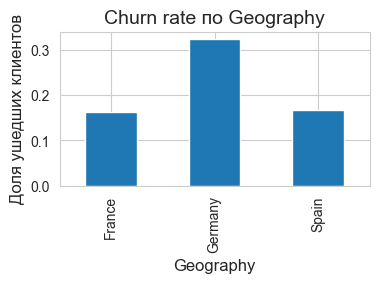


Распределение по Gender:


Gender
Female    0.250715
Male      0.164743
Name: Exited, dtype: float64

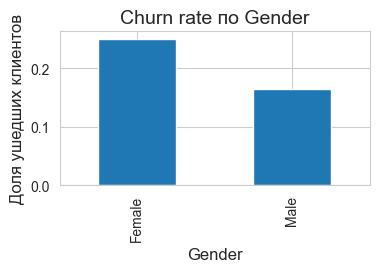


Распределение по Card Type:


Card Type
DIAMOND     0.217790
GOLD        0.192646
PLATINUM    0.203607
SILVER      0.201122
Name: Exited, dtype: float64

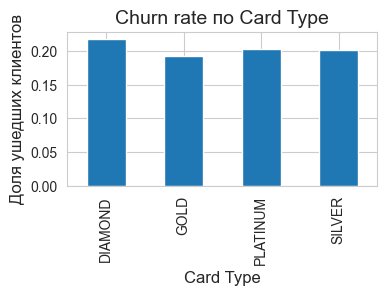

In [54]:
categoricals = ['Geography', 'Gender', 'Card Type']

for col in categoricals:
    print(f"\nРаспределение по {col}:")
    churn_by_category = df.groupby(col)['Exited'].mean()
    display(churn_by_category)
    
    churn_by_category.plot(kind='bar', figsize=(4,2), title=f"Churn rate по {col}")
    plt.ylabel("Доля ушедших клиентов")
    plt.show()

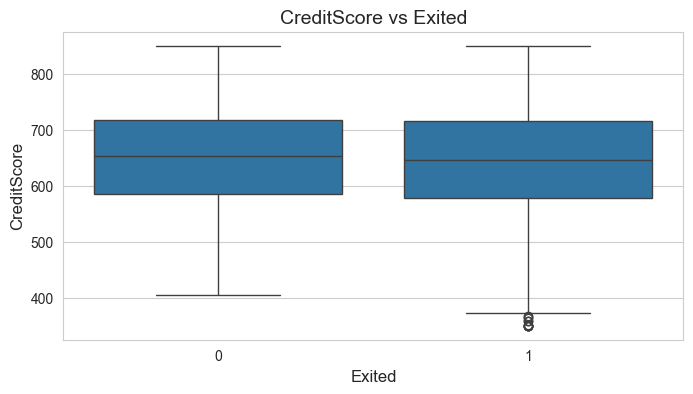

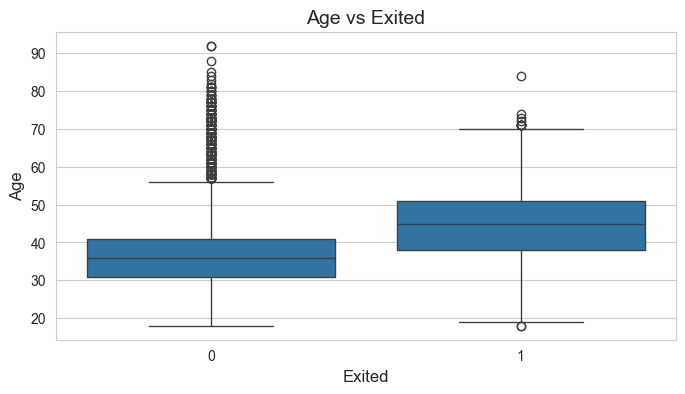

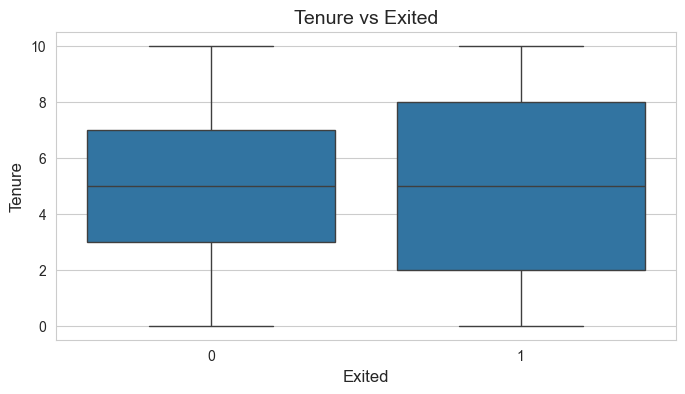

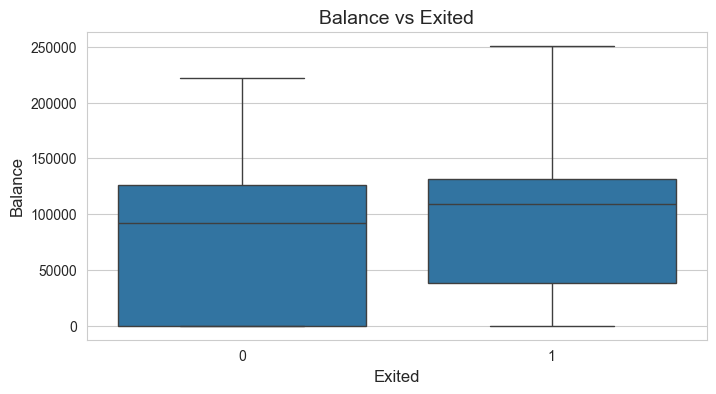

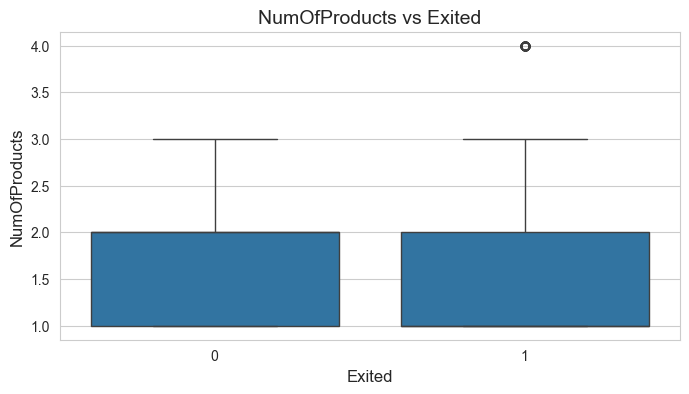

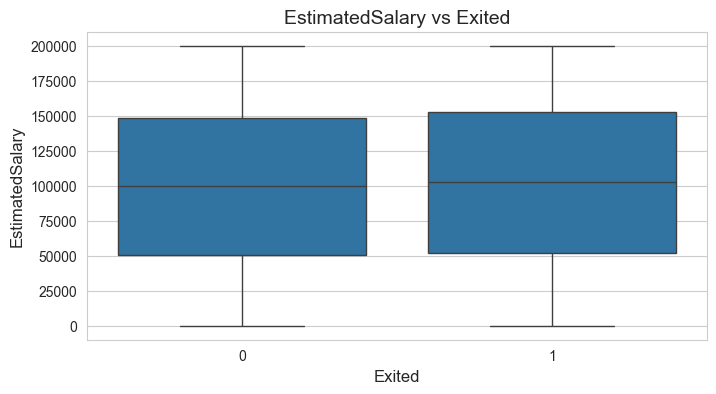

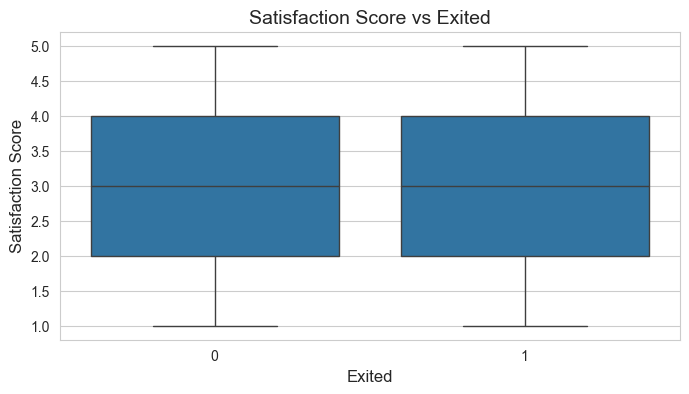

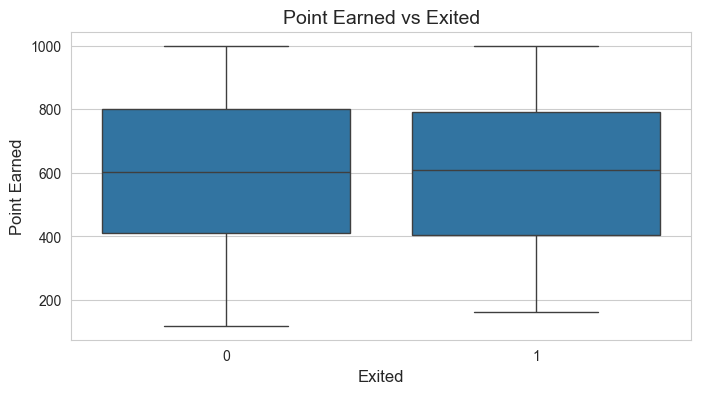

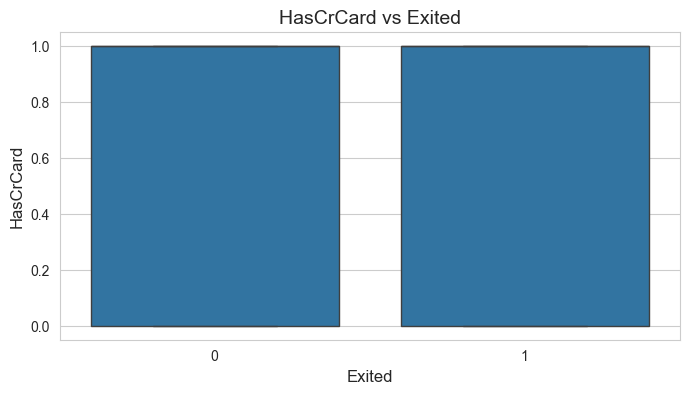

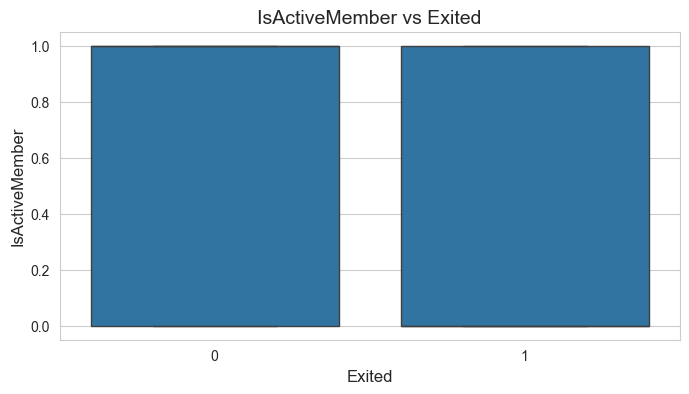

In [55]:
numericals = ['CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'EstimatedSalary', 'Satisfaction Score', 'Point Earned', 'HasCrCard', 'IsActiveMember']

for col in numericals:
    plt.figure(figsize=(8,4))
    sns.boxplot(x='Exited', y=col, data=df)
    plt.title(f"{col} vs Exited")
    plt.show()

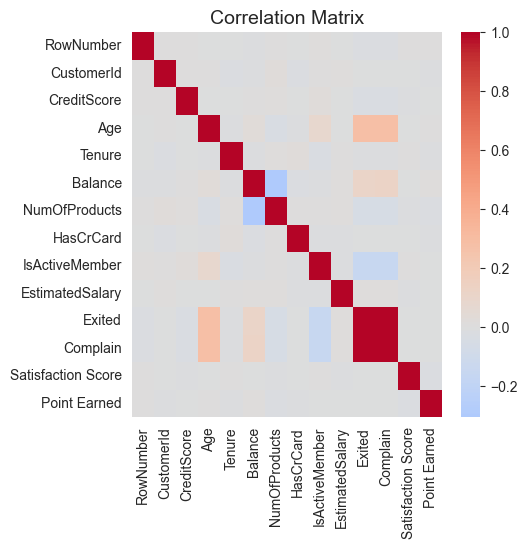

Корреляция признаков с Exited:


Exited                1.000000
Complain              0.995693
Age                   0.285296
Balance               0.118577
EstimatedSalary       0.012490
Point Earned         -0.004628
Satisfaction Score   -0.005849
CustomerId           -0.006203
HasCrCard            -0.006976
Tenure               -0.013656
RowNumber            -0.016140
CreditScore          -0.026771
NumOfProducts        -0.047611
IsActiveMember       -0.156356
Name: Exited, dtype: float64

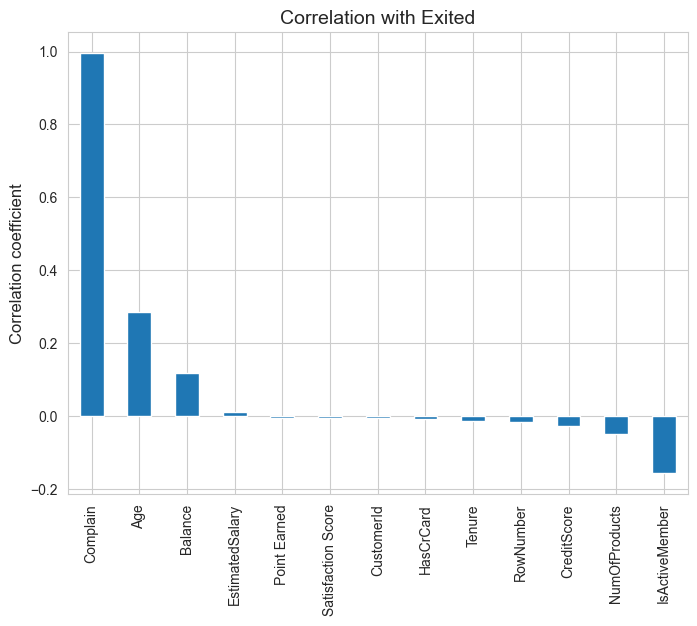

In [56]:
corr_matrix = df.corr(numeric_only=True)

plt.figure(figsize=(5, 5))
sns.heatmap(corr_matrix, 
            annot=False, 
            cmap="coolwarm", 
            center=0)

plt.title("Correlation Matrix")
plt.show()

corr_with_target = corr_matrix["Exited"].sort_values(ascending=False)

print("Корреляция признаков с Exited:")
display(corr_with_target)

plt.figure(figsize=(8,6))
corr_with_target.drop("Exited").plot(kind="bar")
plt.title("Correlation with Exited")
plt.ylabel("Correlation coefficient")
plt.show()


### Выводы по boxplot и корреляционной матрице (до удаления признаков)
#### Анализ по boxplot

По визуальному анализу распределений числовых признаков относительно целевой переменной `Exited`:

`Age` — у ушедших клиентов медианный возраст выше. Это указывает на возможную зависимость вероятности ухода от возраста.

`Balance` — заметна разница в распределении баланса между ушедшими и оставшимися клиентами. Баланс может быть значимым фактором.

`Tenure` — различия присутствуют, но выражены слабее, чем у `Age` и `Balance`.

Остальные числовые признаки демонстрируют меньшие визуальные различия между классами.

Таким образом, `Age` и `Balanc`e выглядят как потенциально важные признаки для модели.

#### Анализ корреляционной матрицы

Корреляция с целевой переменной `Exited` показала:

`Complain` (0.995) — практически идеальная положительная корреляция.

`Age` (0.285) — умеренная положительная связь.

`Balance` (0.118) — слабая положительная связь.

`IsActiveMember` (-0.156) — умеренная отрицательная связь (активные клиенты реже уходят).

Остальные признаки имеют слабую корреляцию (близкую к нулю).

#### Ключевое наблюдение

Признак `Complain` демонстрирует аномально высокую корреляцию с `Exited`, что может свидетельствовать о возможной утечке данных, поскольку жалоба клиента может быть следствием ухода, а не его причиной. Поэтому этот признак требует дополнительного анализа перед использованием в модели.

## 6. Чистка признаков

Удаление нерелевантных и проблемных признаков

Перед построением модели необходимо удалить признаки, которые не несут полезной информации для предсказания оттока или могут привести к некорректному обучению модели.

`RowNumber` — порядковый номер записи. Не содержит информации о поведении клиента.

`CustomerId` — уникальный идентификатор клиента. Не имеет предсказательной ценности.

`Surname` — фамилия клиента. Имеет слишком большое количество уникальных значений и не отражает поведенческих или финансовых характеристик.

`Complain` — данный признак, вероятно, является следствием ухода клиента, а не его причиной. Использование этого признака может привести к утечке данных, когда модель получает информацию, которая в реальной задаче недоступна на момент предсказания. 


In [57]:
columns_to_drop = ['RowNumber', 'CustomerId', 'Surname', 'Complain']
df = df.drop(columns=columns_to_drop)
df.head()

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Satisfaction Score,Card Type,Point Earned
0,619,France,Female,42,2,0.00,1,1,1,101348.88,1,2,DIAMOND,464
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0,3,DIAMOND,456
2,502,France,Female,42,8,159660.80,3,1,0,113931.57,1,3,DIAMOND,377
3,699,France,Female,39,1,0.00,2,0,0,93826.63,0,5,GOLD,350
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0,5,GOLD,425


## 10. Кодирование категориальных признаков

Категориальные признаки были преобразованы в числовой формат для дальнейшего обучения модели.

`Gender` был закодирован в бинарный формат (0/1), поскольку содержит две категории.

`Geography` и `Card Type` были преобразованы с помощью One-Hot Encoding, так как содержат более двух категорий и не имеют естественного порядка.

Параметр `drop_first=True` использован для предотвращения мультиколлинеарности.

In [58]:
df['Gender'] = df['Gender'].map({'Male': 0, 'Female': 1})
one_hot_cols = ['Geography', 'Card Type']
df = pd.get_dummies(df, columns=one_hot_cols, drop_first=True)  
df.head()

,CreditScore,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Satisfaction Score,Point Earned,Geography_Germany,Geography_Spain,Card Type_GOLD,Card Type_PLATINUM,Card Type_SILVER
0,619,1,42,2,0.00,1,1,1,101348.88,1,2,464,False,False,False,False,False
1,608,1,41,1,83807.86,1,0,1,112542.58,0,3,456,False,True,False,False,False
2,502,1,42,8,159660.80,3,1,0,113931.57,1,3,377,False,False,False,False,False
3,699,1,39,1,0.00,2,0,0,93826.63,0,5,350,False,False,True,False,False
4,850,1,43,2,125510.82,1,1,1,79084.10,0,5,425,False,True,True,False,False


## 11. Заключительная подготовка датасета

In [59]:
print(f"Dataset shape: {df.shape}")

missing = df.isnull().sum()
if missing.sum() == 0:
    print("Не обнаружены пропущенные значения")
else:
    print("Пропущенные значения:")
    print(missing[missing > 0])

non_numeric = df.select_dtypes(exclude=['int64', 'float64', 'bool']).columns
if len(non_numeric) == 0:
    print("Все признаки преобразованы к числовому формату")
else:
    print("Обнаружены признаки, не являющиеся числовыми:")
    print(list(non_numeric))

X = df.drop("Exited", axis=1)
y = df["Exited"]

print(f"Размер матрицы признаков: {X.shape}")
print(f"Размер вектора целевых переменных: {y.shape}")

df.to_csv("../data/processed_data.csv", index=False)
print("Обновленный датасет загружен!")

Dataset shape: (10000, 17)
Не обнаружены пропущенные значения
Все признаки преобразованы к числовому формату
Размер матрицы признаков: (10000, 16)
Размер вектора целевых переменных: (10000,)
Обновленный датасет загружен!


- Проведен EDA анализ датасета клиентов банка.
- Удалены нерелевантные и потенциально проблемные признаки: RowNumber, CustomerId, Surname, Complain (утечка данных).
- Категориальные признаки закодированы:
- Gender → бинарное кодирование (0/1)
- Geography и Card Type → one-hot encoding с drop_first=True
- Проведен анализ числовых признаков (boxplots) и корреляций с Exited.
- Age и Balance показали умеренное влияние на отток.
- IsActiveMember отрицательно коррелирует с оттоком (активные клиенты уходят реже).
- Проверены типы данных, пропуски отсутствуют.

Датасет готов к построению моделей машинного обучения.